In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, concatenate, LSTM, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import string
import random
from random import randint
import os
from PIL import Image, ImageFont, ImageDraw
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Load Character Recognition Model

In [ ]:
from tensorflow.keras.models import load_model
char_model = load_model('character_rec.keras')

In [ ]:
char_model.summary()  # Check architecture
import numpy as np
test_input = np.random.rand(1, 183, 256, 3)  # Match input shape
print(char_model.predict(test_input))  # Test inference

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 181, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 127, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 88, 125, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 44, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 42, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 21, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 80640)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 80640)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 200)                 │      16,128,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           4,824 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,452,546 (123.80 MB)

 Trainable params: 16,226,272 (61.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,226,274 (61.90 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
[[          0           0           0           0           0           0           0           0           1           0           0           0           0           0           0           0           0           0           0           0           0           0           0  3.8143e-23]]


#test Countour Detection

In [ ]:
import numpy as np
import cv2

im = cv2.imread('/content/processed/CRIMEPILLOWFIGHT:0.png')
assert im is not None, "file could not be read, check with os.path.exists()"
imgray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(imgray, 127, 255, 0)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cv2_imshow(thresh)

AssertionError: file could not be read, check with os.path.exists()

In [ ]:
cv2.drawContours(im, contours, -1, (0,255,0), 3)

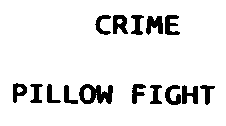

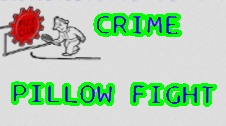

Total contours: 20, Filtered contours: 19


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Remove if not in Colab

# Load image
im = cv2.imread('/content/0089_CRIMEPILLOWFIGHT_1_aug_7.jpg')
height, width = im.shape[:2]

# Define border exclusion (10%)
border_percent = 0.03
left = int(width * border_percent)
right = int(width * (1 - border_percent))
top = int(height * border_percent)
bottom = int(height * (1 - border_percent))

# Process image (original code)
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])
mask = cv2.inRange(hsv, lower_blue, upper_blue)
mask = cv2.bitwise_not(mask)  # Invert mask (text=white)

# Find all contours
contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours: Keep only those fully inside the inner 80% region
filtered_contours = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    # Check if contour is entirely within the inner 80% region
    if (x >= left and (x + w) <= right and
        y >= top and (y + h) <= bottom):
        filtered_contours.append(cnt)

# Draw filtered contours on original image
output = im.copy()
cv2.drawContours(output, filtered_contours, -1, (0, 255, 0), 2)  # Green contours

# Display results
cv2_imshow(mask)
cv2_imshow(output)
print(f"Total contours: {len(contours)}, Filtered contours: {len(filtered_contours)}")

#Obtain Clue Boards


In [ ]:
import cv2
import numpy as np
import os

# Path to the directory containing images
image_dir = '/content/ClueBoards'
output_dir = '/content/ProcessedClueBoards'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load image files
image_files = [
    f for f in os.listdir(image_dir)
    if os.path.isfile(os.path.join(image_dir, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

# Function to order points in a consistent way
def order_points(pts):
    """
    Orders the points in a consistent order:
    [top-left, top-right, bottom-right, bottom-left]
    """
    rect = np.zeros((4, 2), dtype="float32")

    # Sum of x and y coordinates (top-left will have the smallest sum, bottom-right the largest)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right

    # Compute the difference (top-right will have the smallest difference, bottom-left the largest)
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect

# Function to process image
def process_image(image_path, output_path, output_size=(300, 150)):
    # Load the image
    image = cv2.imread(image_path)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define range for blue color detection (Adjusted lower bound)
    lower_blue = np.array([102, 124, 80])  # User-defined adjustment
    upper_blue = np.array([140, 255, 255])

    # Threshold the blue region
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print(f"No blue box detected in {image_path}")
        return

    # Find the largest rectangular contour
    largest_contour = max(contours, key=cv2.contourArea)

    # Approximate the contour with a polygon
    epsilon = 0.02 * cv2.arcLength(largest_contour, True)
    approx = cv2.approxPolyDP(largest_contour, epsilon, True)

    if len(approx) == 4:  # Ensure it's a quadrilateral
        pts_src = np.array([point[0] for point in approx], dtype="float32")

        # Order the points correctly
        ordered_pts = order_points(pts_src)

        # Define the standard output rectangle
        (width, height) = output_size
        pts_dst = np.array([
            [0, 0], [width - 1, 0],
            [width - 1, height - 1], [0, height - 1]
        ], dtype="float32")

        # Compute the perspective transform matrix
        M = cv2.getPerspectiveTransform(ordered_pts, pts_dst)

        # Apply the transformation
        warped = cv2.warpPerspective(image, M, output_size)

        # Save the processed image
        cv2.imwrite(output_path, warped)
        print(f"Processed and saved: {output_path}")
    else:
        print(f"Could not find a clear rectangle in {image_path}")

# Process each image
for image_file in image_files:
    input_path = os.path.join(image_dir, image_file)
    output_path = os.path.join(output_dir, image_file)
    process_image(input_path, output_path)

print("Processing complete.")


Processed and saved: /content/ProcessedClueBoards/WEAPONRAPTORFLUX:0.png
Processed and saved: /content/ProcessedClueBoards/299958:.png
Processing complete.


In [ ]:
rm -rf /content/ProcessedClueBoards

#Load Images

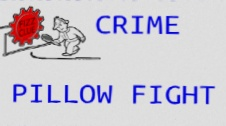

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the image
image_path = "/content/0089_CRIMEPILLOWFIGHT_1_aug_7.jpg"
image = cv2.imread(image_path)



# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define a refined blue color range
lower_blue = np.array([0, 3, 0])  # Adjusted to be more accurate
upper_blue = np.array([255, 255, 255])

# Create a mask to detect blue pixels
blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

# Invert the mask to focus on the non-blue area
mask_inv = cv2.bitwise_not(blue_mask)

# Apply morphological operations to clean up noise
kernel = np.ones((3,3), np.uint8)
mask_inv = cv2.morphologyEx(mask_inv, cv2.MORPH_CLOSE, kernel, iterations=2)

# Find contours in the non-blue mask
contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# If contours are found, crop to the bounding box of the largest detected content area
if contours:
    x, y, w, h = cv2.boundingRect(np.concatenate(contours))
    final_cropped = image[y:y+h, x:x+w]
else:
    final_cropped = image  # If nothing is found, keep original

# Show the final cleaned image
cv2_imshow(final_cropped)



In [ ]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

# Path to the directory containing images
image_dir = "/content/ProcessedClueBoards"
output_dir = "/content/processed"  # Directory to save cropped images
os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

# List all image files
image_files = [
    f for f in os.listdir(image_dir)
    if os.path.isfile(os.path.join(image_dir, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))
]
image_files.sort()  # Sort for consistency

def remove_blue_border(image_path, save_path):
    """Removes blue border from an image and saves the cropped result."""
    image = cv2.imread(image_path)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define blue range
    lower_blue = np.array([0, 2, 0])
    upper_blue = np.array([255, 255, 255])

    # Create mask and clean noise
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    mask_inv = cv2.bitwise_not(mask)
    kernel = np.ones((3,3), np.uint8)
    mask_inv = cv2.morphologyEx(mask_inv, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Find contours and crop
    contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(np.concatenate(contours))
        cropped = image[y:y+h, x:x+w]
    else:
        cropped = image  # Keep original if nothing is found

    cv2.imwrite(save_path, cropped)  # Save cropped image

# Process all images
processed_images = []
for filename in image_files:
    input_path = os.path.join(image_dir, filename)
    output_path = os.path.join(output_dir, filename)

    remove_blue_border(input_path, output_path)
    processed_images.append(output_path)

print(f"Processed {len(processed_images)} images and saved to {output_dir}")



Processed 2 images and saved to /content/processed


###hide

In [ ]:
# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=1,
    brightness_range=[1.0, 1.2],

)

augset = []
imgset = []

# Generate augmented images
for image_path in processed_images:
    image = Image.open(image_path)
    image_array = np.expand_dims(np.array(image), 0)  # Convert to array and add batch dimension

    filename_prefix = os.path.basename(image_path).split(':')[0]

    aug_iter = datagen.flow(image_array, batch_size=1)
    for _ in range(10):  # Generate 10 augmented versions
        augmented_image = next(aug_iter)[0].astype('uint8')
        imgset.append(augmented_image)
        augset.append([augmented_image, filename_prefix])  # Store with filename prefix

print(f"Total images in augset: {len(augset)}")  # Original + augmented


##sdjkb

In [ ]:
rm -rf final

In [ ]:
import cv2
import numpy as np
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directory paths
processed_dir = "/content/processed"
final_dir = "/content/final"

# Create output directory
os.makedirs(final_dir, exist_ok=True)

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=1,
    brightness_range=[1.0, 1.2],
)

# Get list of processed images
processed_images = [f for f in os.listdir(processed_dir)
                  if os.path.isfile(os.path.join(processed_dir, f)) and
                  f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# List to store all images and their future filenames
all_images = []
file_names = []

# Process each image
for filename in processed_images:
    # Read image
    img_path = os.path.join(processed_dir, filename)
    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read image: {img_path}")
        continue

    # Convert to RGB (Keras works with RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Reshape for generator (1, height, width, channels)
    img_array = np.expand_dims(img_rgb, axis=0)

    # Store original image
    base_name = os.path.splitext(filename)[0]
    all_images.append(img)
    file_names.append(f"{base_name}_original.png")

    # Generate augmented images
    save_count = 0
    for batch in datagen.flow(img_array, batch_size=1):
        # Convert back to BGR for OpenCV
        aug_img = cv2.cvtColor(batch[0].astype('uint8'), cv2.COLOR_RGB2BGR)
        all_images.append(aug_img)
        file_names.append(f"{base_name}_aug_{save_count}.png")

        save_count += 1
        if save_count >= 10:
            break

# Shuffle the images and filenames together
combined = list(zip(all_images, file_names))
random.shuffle(combined)
all_images[:], file_names[:] = zip(*combined)

# Save all shuffled images
for img, filename in zip(all_images, file_names):
    output_path = os.path.join(final_dir, filename)
    cv2.imwrite(output_path, img)

print(f"\nSuccessfully saved {len(all_images)} shuffled images to {final_dir}")
print(f"Breakdown:")
print(f"- {len(processed_images)} original images")
print(f"- {len(processed_images)*10} augmented images")
print("All images have been shuffled before saving.")


Successfully saved 99 shuffled images to /content/final
Breakdown:
- 9 original images
- 90 augmented images
All images have been shuffled before saving.


In [ ]:
np.random.shuffle(augset)

In [ ]:
np.random.shuffle(imgset)

'WEAPONTICKLEGUN'

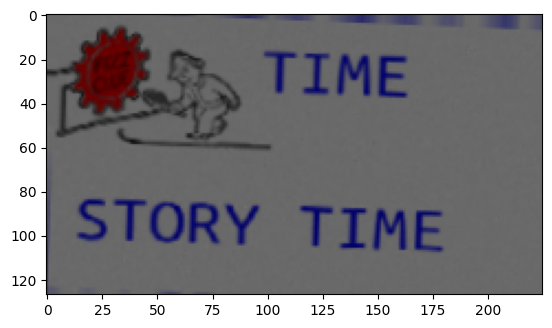

In [ ]:
plt.imshow(augset[8][0])
augset[0][1]

WEAPONTICKLEGUN


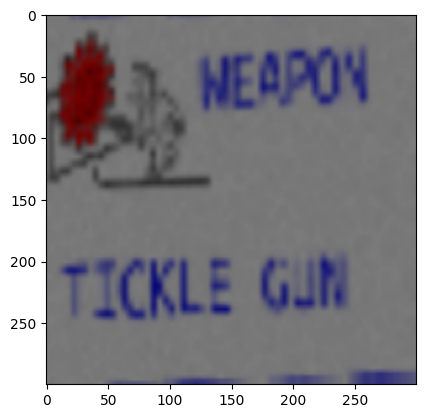

In [ ]:
# Genereate X and Y datasets
X_dataset_orig = [data[0] for data in augset]  # Remove [:] which is unnecessary
Y_dataset = np.array([data[1] for data in augset])

# Ensure all images have the same shape
common_shape = (300, 300, 3)  # Example shape, adjust if needed
X_dataset_orig = np.array([cv2.resize(img, common_shape[:2]) for img in X_dataset_orig])

# Normalize X (images) dataset
X_dataset = X_dataset_orig / 255.0
plt.imshow(X_dataset_orig[0])
print(Y_dataset[0])

In [ ]:
from ipywidgets import interact
import ipywidgets as ipywidgets

# Display images in the training data set.
def displayImage(index):
  plt.imshow(X_dataset[index])
  caption = ("y = " + str(Y_dataset[index]))#str(np.squeeze(Y_dataset_orig[:, index])))
  plt.text(0.5, 0.5, caption,
           color='orange', fontsize = 10,
           horizontalalignment='left', verticalalignment='top')


interact(displayImage,
         index=ipywidgets.IntSlider(min=0, max=X_dataset_orig.shape[0],
                                    step=1, value=10))
#displayImage(2)

interactive(children=(IntSlider(value=10, description='index', max=130), Output()), _dom_classes=('widget-inte…

<function __main__.displayImage(index)>

#Word Detection

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def detect_words(image_path, output_txt):
    # Load image
    image = cv2.imread(image_path)
    height, width = image.shape[:2]

    # Define border exclusion (3%)
    border_percent = 0.03
    left = int(width * border_percent)
    right = int(width * (1 - border_percent))
    top = int(height * border_percent)
    bottom = int(height * (1 - border_percent))

    # Preprocessing - enhance text visibility
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations to connect nearby text components
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    dilated = cv2.dilate(thresh, kernel, iterations=2)

    # Find contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter contours by size and position
    filtered_contours = []
    min_area = 50  # Minimum area for a single character
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h

        # Filter by area and border exclusion
        if (area >= min_area and
            x >= left and (x + w) <= right and
            y >= top and (y + h) <= bottom):
            filtered_contours.append(cnt)

    # Improved contour grouping algorithm
    def group_contours(contours, max_char_gap=0.07, max_line_gap=1.5):
        if not contours:
            return []

        # Get bounding boxes with contour indices
        boxes = [(i, cv2.boundingRect(c)) for i, c in enumerate(contours)]

        # Calculate typical character height (median of all heights)
        char_height = np.median([h for (_, (_, _, _, h)) in boxes])

        # Group by lines first (y-axis)
        boxes_sorted_y = sorted(boxes, key=lambda b: b[1][1])
        lines = []
        current_line = [boxes_sorted_y[0]]

        for box in boxes_sorted_y[1:]:
            last_box = current_line[-1]
            # Vertical gap in terms of character heights
            vertical_gap = (box[1][1] - (last_box[1][1] + last_box[1][3])) / char_height

            if vertical_gap < max_line_gap:
                current_line.append(box)
            else:
                lines.append(current_line)
                current_line = [box]

        if current_line:
            lines.append(current_line)

        # Group within each line (x-axis)
        word_groups = []
        for line in lines:
            # Sort boxes in line by x coordinate
            line_sorted_x = sorted(line, key=lambda b: b[1][0])
            current_word = [line_sorted_x[0]]

            for box in line_sorted_x[1:]:
                last_box = current_word[-1]
                # Horizontal gap in terms of character widths
                char_width = last_box[1][2]
                horizontal_gap = (box[1][0] - (last_box[1][0] + last_box[1][2])) / char_width

                if horizontal_gap < max_char_gap:
                    current_word.append(box)
                else:
                    word_groups.append(current_word)
                    current_word = [box]

            if current_word:
                word_groups.append(current_word)

        return word_groups

    # Group contours into words
    word_groups = group_contours(filtered_contours)

    # Create bounding boxes for each word group
    output_image = image.copy()
    boxes = []

    for group in word_groups:
        # Get all bounding boxes in this group
        group_boxes = [box[1] for box in group]

        # Calculate combined bounding box
        x = min(box[0] for box in group_boxes)
        y = min(box[1] for box in group_boxes)
        right = max(box[0] + box[2] for box in group_boxes)
        bottom = max(box[1] + box[3] for box in group_boxes)
        w = right - x
        h = bottom - y

        # Draw bounding box
        cv2.rectangle(output_image, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Convert to YOLO format
        x_center = (x + w/2)/width
        y_center = (y + h/2)/height
        norm_w = w/width
        norm_h = h/height
        boxes.append(f"0 {x_center} {y_center} {norm_w} {norm_h}")

    # Display results
    cv2_imshow(output_image)
    print(f"Detected {len(boxes)} words")

    # Save to file
    with open(output_txt, "w") as f:
        f.write("\n".join(boxes))


In [ ]:
rm -rf labels

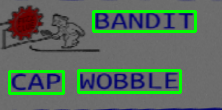

Detected 3 words


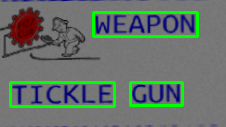

Detected 3 words


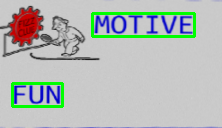

Detected 2 words


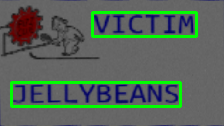

Detected 2 words


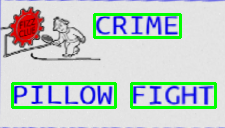

Detected 3 words


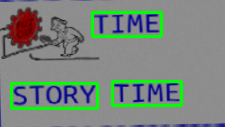

Detected 3 words


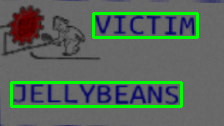

Detected 2 words


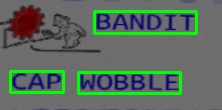

Detected 3 words


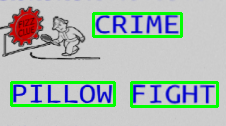

Detected 3 words


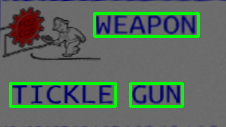

Detected 3 words


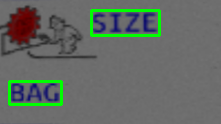

Detected 2 words


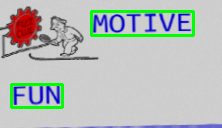

Detected 2 words


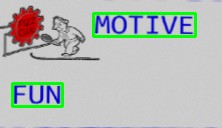

Detected 2 words


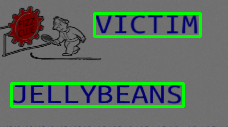

Detected 2 words


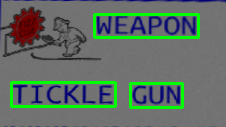

Detected 3 words


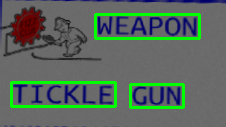

Detected 3 words


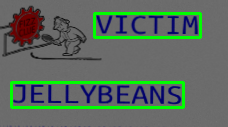

Detected 2 words


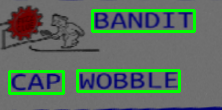

Detected 3 words


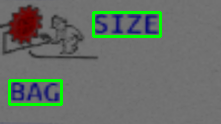

Detected 2 words


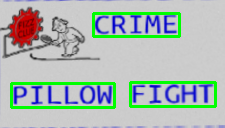

Detected 3 words


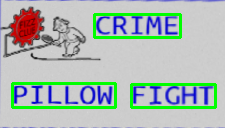

Detected 3 words


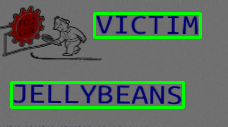

Detected 2 words


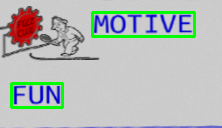

Detected 2 words


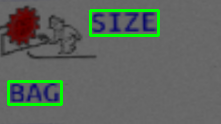

Detected 2 words


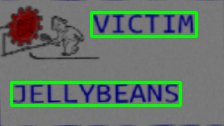

Detected 2 words


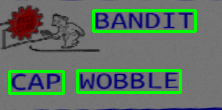

Detected 3 words


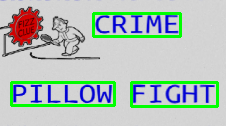

Detected 3 words


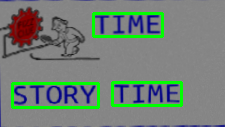

Detected 3 words


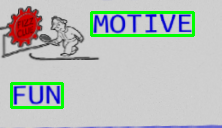

Detected 2 words


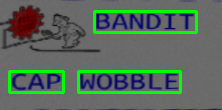

Detected 3 words


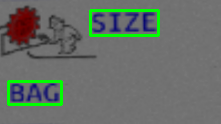

Detected 2 words


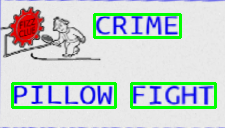

Detected 3 words


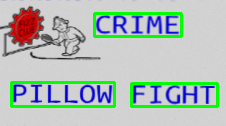

Detected 3 words


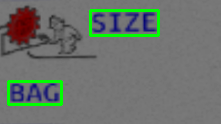

Detected 2 words


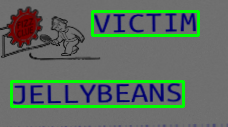

Detected 2 words


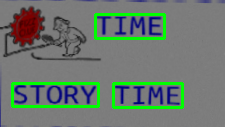

Detected 3 words


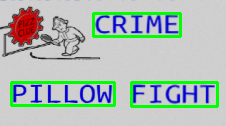

Detected 3 words


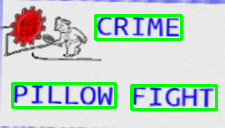

Detected 3 words


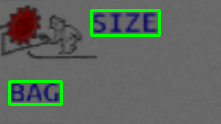

Detected 2 words


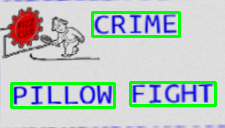

Detected 3 words


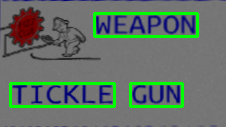

Detected 3 words


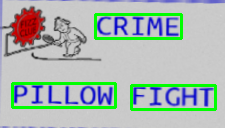

Detected 3 words


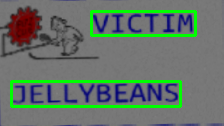

Detected 2 words


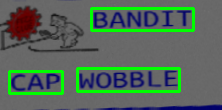

Detected 3 words


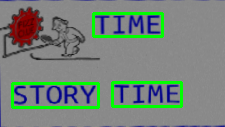

Detected 3 words


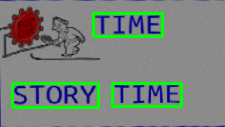

Detected 3 words


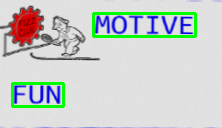

Detected 2 words


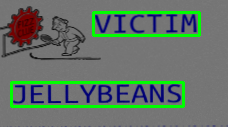

Detected 2 words


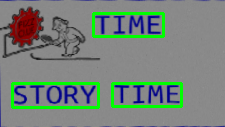

Detected 3 words


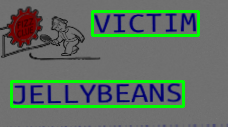

Detected 2 words


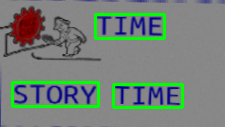

Detected 3 words


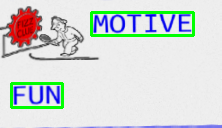

Detected 2 words


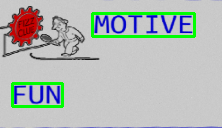

Detected 2 words


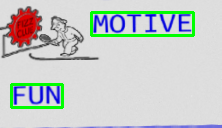

Detected 2 words


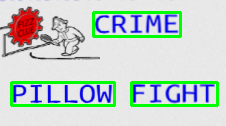

Detected 3 words


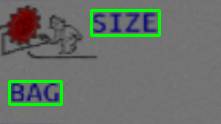

Detected 2 words


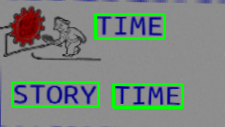

Detected 3 words


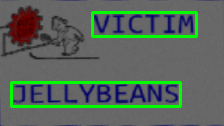

Detected 2 words


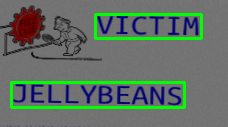

Detected 2 words


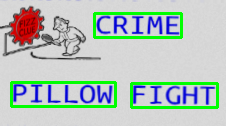

Detected 3 words


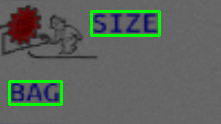

Detected 2 words


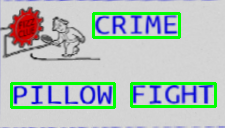

Detected 3 words


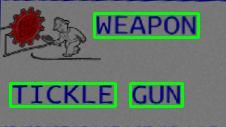

Detected 3 words


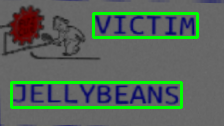

Detected 2 words


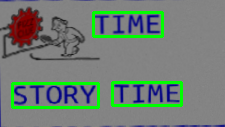

Detected 3 words


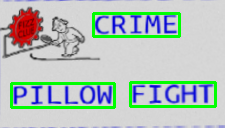

Detected 3 words


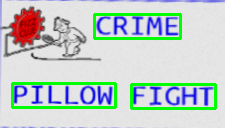

Detected 3 words


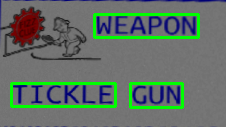

Detected 3 words


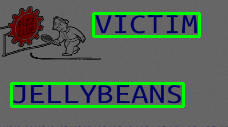

Detected 2 words


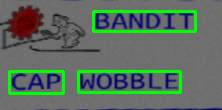

Detected 3 words


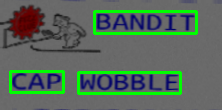

Detected 3 words


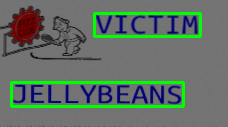

Detected 2 words


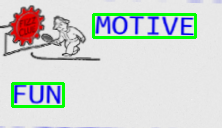

Detected 2 words


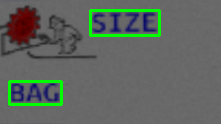

Detected 2 words


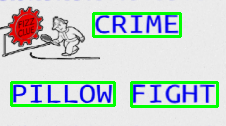

Detected 3 words


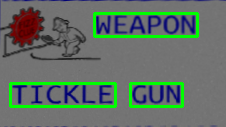

Detected 3 words


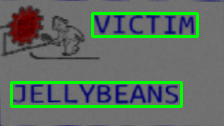

Detected 2 words


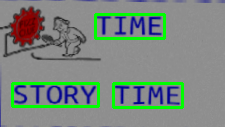

Detected 3 words


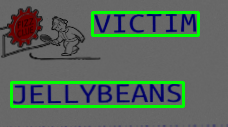

Detected 2 words


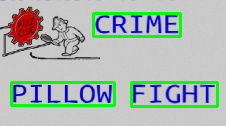

Detected 3 words


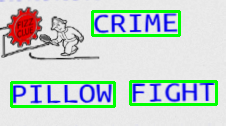

Detected 3 words


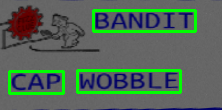

Detected 3 words


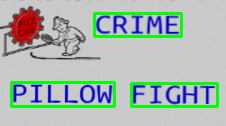

Detected 3 words


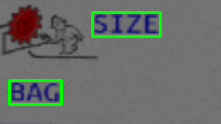

Detected 2 words


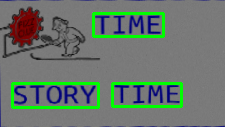

Detected 3 words


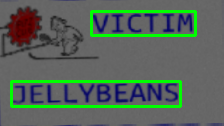

Detected 2 words


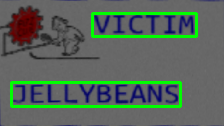

Detected 2 words


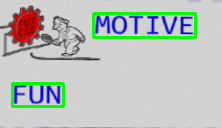

Detected 2 words


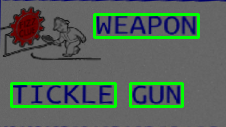

Detected 3 words


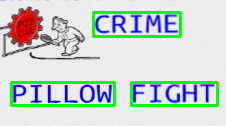

Detected 3 words


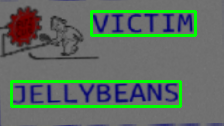

Detected 2 words


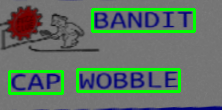

Detected 3 words


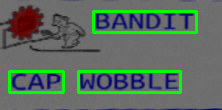

Detected 3 words


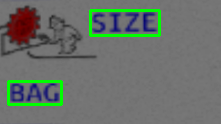

Detected 2 words


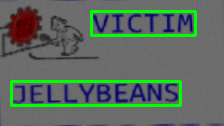

Detected 2 words


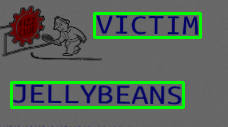

Detected 2 words


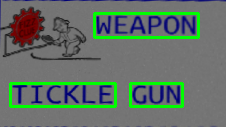

Detected 3 words


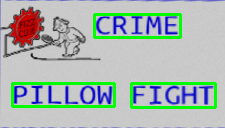

Detected 3 words


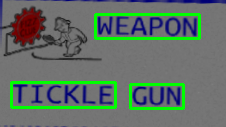

Detected 3 words


In [ ]:

# Example Usage
image_folder = "/content/final"
label_folder = "/content/labels"

os.makedirs(label_folder, exist_ok=True)

for image_file in os.listdir(image_folder):
    if image_file.endswith(".jpg") or image_file.endswith(".png"):
        img_path = os.path.join(image_folder, image_file)
        label_path = os.path.join(label_folder, image_file.replace(".jpg", ".txt").replace(".png", ".txt"))
        detect_words(img_path, label_path)

#Model

In [ ]:
pip install ultralytics


In [ ]:
import os
import shutil

# Define paths
dataset_path = "/content/yolo_dataset"

# Create YOLO dataset folders
os.makedirs(f"{dataset_path}/train/images", exist_ok=True)
os.makedirs(f"{dataset_path}/train/labels", exist_ok=True)
os.makedirs(f"{dataset_path}/val/images", exist_ok=True)
os.makedirs(f"{dataset_path}/val/labels", exist_ok=True)

# Move images (80% train, 20% val)
images = sorted(os.listdir("/content/final"))  # Ensure order is maintained
labels = sorted(os.listdir("/content/labels"))  # Ensure order is maintained

split_index = int(len(images) * 0.8)  # 80% train, 20% val

for i, img_file in enumerate(images):
    src_img = os.path.join("/content/final", img_file)
    src_label = os.path.join("/content/labels", labels[i])  # Corresponding label

    if i < split_index:
        shutil.move(src_img, f"{dataset_path}/train/images/{img_file}")
        shutil.move(src_label, f"{dataset_path}/train/labels/{labels[i]}")
    else:
        shutil.move(src_img, f"{dataset_path}/val/images/{img_file}")
        shutil.move(src_label, f"{dataset_path}/val/labels/{labels[i]}")

print("✅ Dataset organized successfully!")


✅ Dataset organized successfully!


In [ ]:
yaml_content = """train: /content/yolo_dataset/train/images
val: /content/yolo_dataset/val/images
nc: 1  # Number of classes
names: ['word']  # Change this if you have multiple classes
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml created successfully!")


✅ data.yaml created successfully!


In [ ]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8s.pt")

# Verify dataset
model.train(data="/content/yolo_dataset/data.yaml", epochs=1, imgsz=640)


Ultralytics 8.3.100 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/yolo_dataset/data.yaml, epochs=1, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_box

train: Scanning /content/yolo_dataset/train/labels... 79 images, 0 backgrounds, 0 corrupt: 100%|██████████| 79/79 [00:00<00:00, 1667.28it/s]

train: New cache created: /content/yolo_dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/yolo_dataset/val/labels... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<00:00, 1802.14it/s]

val: New cache created: /content/yolo_dataset/val/labels.cache
Plotting labels to runs/detect/train/labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1         0G      1.784       3.88      1.525         94        640:  20%|██        | 1/5 [00:44<02:57, 44.39s/it]


KeyboardInterrupt: 